<a href="https://colab.research.google.com/github/gauravkasture007/My-CPS-Project/blob/main/ConnectTel_Telecom_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
print("✅ Interactive data tables enabled!")

✅ Interactive data tables enabled!


In [143]:
# =================================================================
# 1. CONSOLIDATED LIBRARIES & DEPENDENCIES
# =================================================================
import os
import sqlite3
import joblib
import re
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Machine Learning & Modeling core stack
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Colab-specific utils
from google.colab import drive, data_table

# Global Viz Config
data_table.enable_dataframe_formatter()
sns.set_theme(style='whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All production libraries consolidated and configured!")

✅ All production libraries consolidated and configured!


# Loading Data from Google Drive
This section mounts your Google Drive to access files directly within the Colab environment.

In [95]:
# =================================================================
# CONNECTTEL CHURN PREDICTION PIPELINE: MOUNT DRIVE
# =================================================================
# Mount Google Drive (Libraries are already loaded above)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now we will search for the file and load it into a pandas DataFrame. If the file is not a CSV, you may need to change `read_csv` to the appropriate function.

In [4]:
# Define the file name
file_name = 'telecom_churn.csv' # Adjust extension if necessary (e.g., .xlsx)

# Typical path for files in the root of 'My Drive'
file_path = f'/content/drive/My Drive/{file_name}'

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the filename and path.")

File loaded successfully!


,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,...,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,...,0,0,0.4,1133.57,High,13,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,...,0,1,5.4,688.54,Medium,41,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,...,1,0,0.0,307.05,Low,53,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,...,1,0,0.0,214.89,Low,20,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,...,0,0,0.5,383.99,Low,17,2.6,0,0,0


In [5]:
df.describe()

,customer_id,age,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,...,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,112499.500000,45.960200,60.149600,475.518315,27230.695507,25.107675,602.187920,50.652920,55.209308,0.24872,...,1.993360,0.401440,0.200040,1.285748,477.978036,20.097920,3.789316,0.151400,0.100040,0.414280
std,7217.022701,16.401422,34.374772,267.550787,23717.163861,9.907997,247.929808,28.547638,43.627134,0.43228,...,1.418604,0.490199,0.400038,1.686236,267.818407,24.896257,0.672727,0.358446,0.300059,0.492607
min,100000.000000,18.000000,1.000000,99.000000,159.030000,0.500000,30.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,99.000000,-80.000000,1.000000,0.000000,0.000000,0.000000
25%,106249.750000,32.000000,31.000000,300.607500,10310.812500,18.390000,432.000000,30.000000,23.517500,0.00000,...,1.000000,0.000000,0.000000,0.200000,302.170000,3.000000,3.300000,0.000000,0.000000,0.000000
50%,112499.500000,46.000000,60.000000,385.735000,20840.650000,25.100000,603.000000,50.000000,50.790000,0.00000,...,2.000000,0.000000,0.000000,0.700000,387.870000,20.000000,3.800000,0.000000,0.000000,0.000000
75%,118749.250000,60.000000,90.000000,601.250000,36884.147500,31.820000,770.250000,70.000000,79.060000,0.00000,...,3.000000,1.000000,0.000000,1.500000,604.402500,37.000000,4.300000,0.000000,0.000000,1.000000
max,124999.000000,74.000000,119.000000,1603.490000,177878.030000,71.800000,1848.000000,173.000000,451.590000,1.00000,...,9.000000,1.000000,1.000000,11.000000,1603.490000,100.000000,5.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  object 
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  object 
 4   connection_type                 25000 non-null  object 
 5   plan_type                       25000 non-null  object 
 6   contract_type                   25000 non-null  object 
 7   base_plan_category              25000 non-null  object 
 8   tenure_months                   25000 non-null  int64  
 9   monthly_charges                 25000 non-null  float64
 10  total_charges                   25000 non-null  float64
 11  avg_data_gb_month               25000 non-null  float64
 12  avg_voice_mins_month            

In [109]:
# Setting up an in-memory SQL engine so we can run quick queries without pandas overhead
conn = sqlite3.connect(':memory:')

try:
    # Load the cleaned dataframe into our temp SQL table
    df.to_sql('telecom_data', conn, index=False, if_exists='replace')
    print("SQL Engine online: Table 'telecom_data' created.")
except NameError:
    print("Check data loading step - 'df' is missing.")

# Helper variables for the UI filters
segments = df['segment_value'].dropna().unique().tolist()
max_tenure = int(df['tenure_months'].max())

def interactive_churn_dashboard(Segment, Max_Tenure):
    """
    Core callback for the dashboard. Fetches filtered aggregates via SQL
    and pipes them into our viz subplots.
    """

    # Note: Using SQL here for complex aggregations as it's often more readable than nested groupby
    query = """
        SELECT
            is_churn,
            COUNT(customer_id) as total_customers,
            AVG(monthly_charges) as avg_monthly_bill,
            AVG(network_issues_3m + num_complaints_3m) as avg_friction
        FROM telecom_data
        WHERE segment_value = ? AND tenure_months <= ?
        GROUP BY is_churn
    """

    result_df = pd.read_sql_query(query, conn, params=(Segment, Max_Tenure))

    if result_df.empty:
        print(f"No matches for {Segment} at {Max_Tenure} months.")
        return

    result_df['Status'] = result_df['is_churn'].map({0: 'Retained', 1: 'Churned'})

    # Visual Layout Setup
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: Volume
    axes[0].bar(result_df['Status'], result_df['total_customers'], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Customer Volume')

    # Chart 2: Billing Impact
    axes[1].bar(result_df['Status'], result_df['avg_monthly_bill'], color=['#3498db', '#9b59b6'])
    axes[1].set_title('Avg Monthly Bill ($)')

    # Chart 3: Experience Friction
    axes[2].bar(result_df['Status'], result_df['avg_friction'], color=['#f1c40f', '#e67e22'])
    axes[2].set_title('Avg Friction Score')

    for ax in axes: ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

# Initialize UI Components
segment_dropdown = widgets.Dropdown(options=segments, description='Segment:')
tenure_slider = widgets.IntSlider(min=1, max=max_tenure, value=max_tenure, description='Tenure Cap:')

display(widgets.HTML("<h3>ConnectTel: Internal SQL Analysis Tool</h3>"))
widgets.interact(interactive_churn_dashboard, Segment=segment_dropdown, Max_Tenure=tenure_slider);

SQL Engine online: Table 'telecom_data' created.


HTML(value='<h3>ConnectTel: Internal SQL Analysis Tool</h3>')

interactive(children=(Dropdown(description='Segment:', options=(0, 2, 1), value=0), IntSlider(value=119, descr…

### Advanced SQL Analysis Section
In this section, we use SQL to perform complex aggregations that might be less intuitive in pure Python. This allows for rapid prototyping of business reports.

In [80]:
# Example: Identifying 'Silent Churners' via SQL
# We define silent churners as those with high tenure but very low recent engagement (app logins)

query = """
SELECT
    customer_id,
    tenure_months,
    monthly_charges,
    app_logins_30d,
    (monthly_charges * tenure_months) as lifetime_value
FROM telecom_data
WHERE app_logins_30d < 2 AND tenure_months > 24
ORDER BY lifetime_value DESC
LIMIT 15
"""

silent_churners_sql = pd.read_sql_query(query, conn)
print("⌛ SQL Query Execution Successful: Top 15 High-Value 'Silent' Customers")
display(silent_churners_sql)

⌛ SQL Query Execution Successful: Top 15 High-Value 'Silent' Customers


,customer_id,tenure_months,monthly_charges,app_logins_30d,lifetime_value
0,124125,118,1111.91,1,131205.38
1,115931,102,1209.31,1,123349.62
2,103393,79,1414.82,1,111770.78
3,111889,80,1308.06,1,104644.80
4,104713,98,1066.80,0,104546.40
5,102818,82,1199.83,1,98386.06
6,119686,115,814.13,1,93624.95
7,108673,87,911.68,1,79316.16
8,108667,70,864.10,1,60487.00
9,121953,79,758.32,1,59907.28


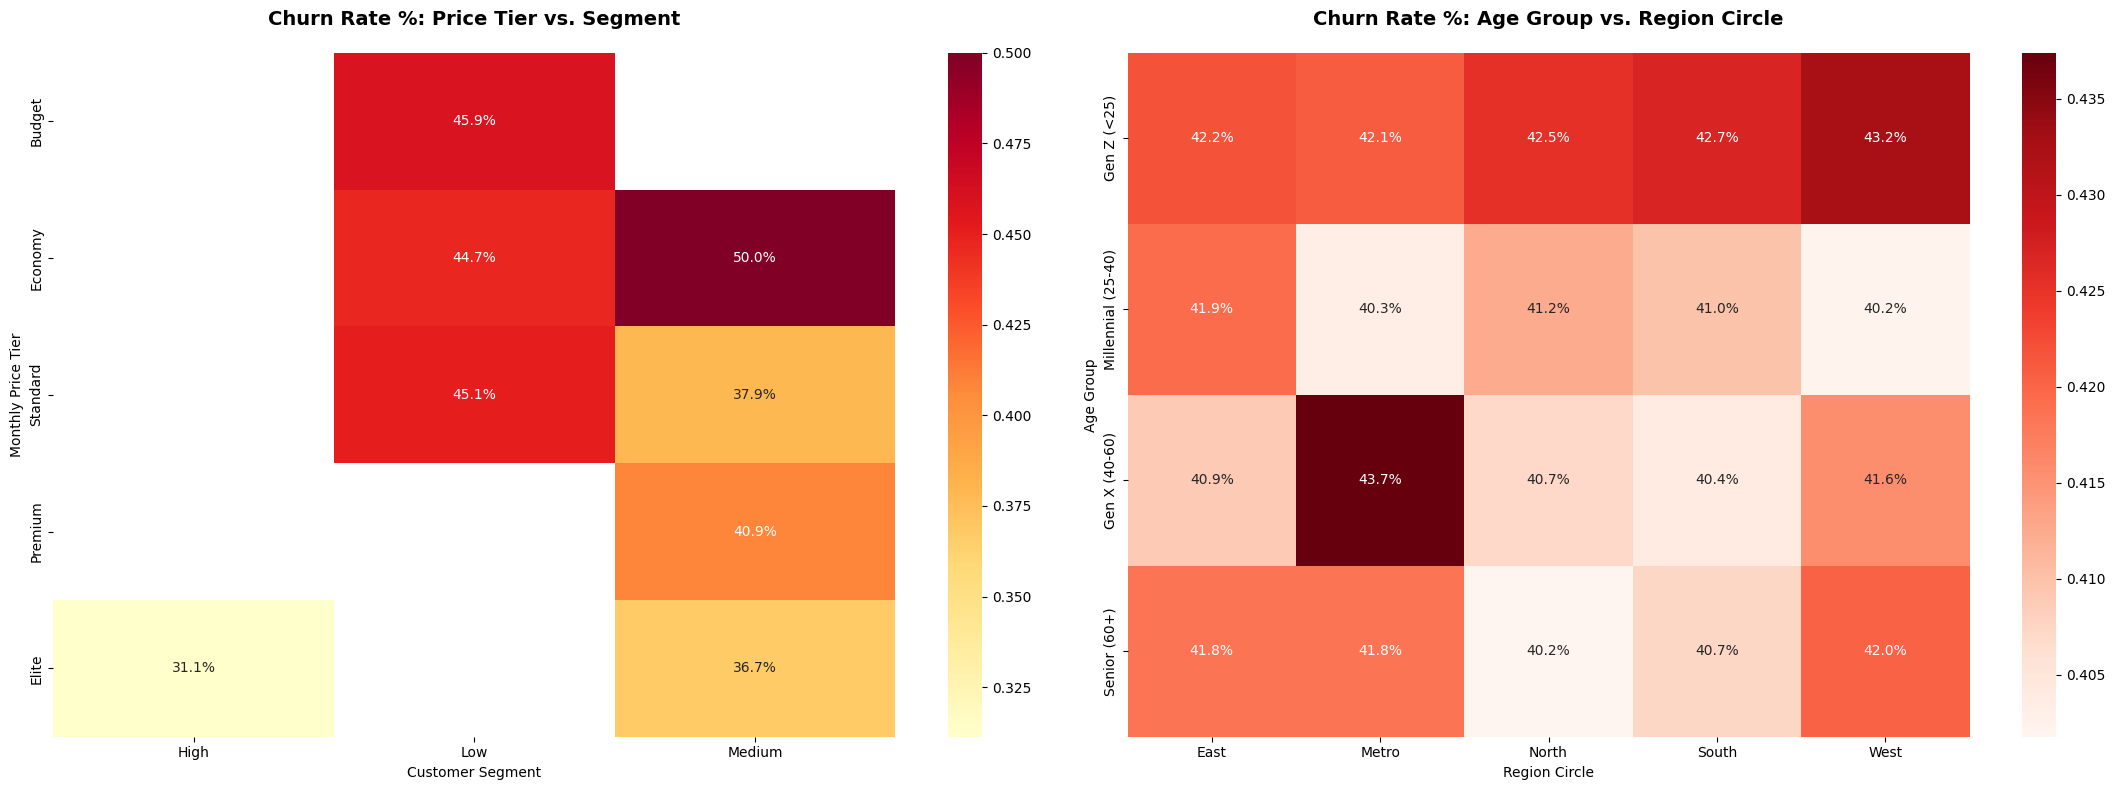

In [10]:
def generate_heatmaps(df):
    # --- 1. CLEANING & SAFETY CHECK ---
    # Standardize column names (lowercase, remove spaces)
    df.columns = [c.lower().strip() for c in df.columns]

    # Updated required columns to match your exact dataset schema
    # Changed 'region' -> 'region_circle'
    required = ['monthly_charges', 'segment_value', 'is_churn', 'age', 'region_circle']
    missing = [col for col in required if col not in df.columns]

    if missing:
        print(f"❌ Error: Still missing columns: {missing}")
        return

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    # --- HEATMAP 1: Churn Rate by Price Bin and Segment ---
    # We use qcut to create 5 equal-sized price tiers
    df['price_bin'] = pd.qcut(df['monthly_charges'], q=5,
                             labels=['Budget', 'Economy', 'Standard', 'Premium', 'Elite'])

    price_churn_map = df.pivot_table(index='price_bin',
                                    columns='segment_value',
                                    values='is_churn',
                                    aggfunc='mean',
                                    observed=False)

    sns.heatmap(price_churn_map, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax1)
    ax1.set_title('Churn Rate %: Price Tier vs. Segment', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('Customer Segment')
    ax1.set_ylabel('Monthly Price Tier')

    # --- HEATMAP 2: Churn Rate by Region Circle and Age Group ---
    # Binning Age into logical life-stage groups
    age_bins = [0, 25, 40, 60, 100]
    age_labels = ['Gen Z (<25)', 'Millennial (25-40)', 'Gen X (40-60)', 'Senior (60+)']
    df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

    # Using 'region_circle' as the column name here
    region_age_map = df.pivot_table(index='age_group',
                                   columns='region_circle',
                                   values='is_churn',
                                   aggfunc='mean',
                                   observed=False)

    sns.heatmap(region_age_map, annot=True, fmt=".1%", cmap="Reds", ax=ax2)
    ax2.set_title('Churn Rate %: Age Group vs. Region Circle', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Region Circle')
    ax2.set_ylabel('Age Group')

    plt.tight_layout()
    plt.show()

# Run the generator
generate_heatmaps(df)

In [11]:
#Logic Check: Total Charges vs Tenure/Monthly Charges
# We'll calculate a 'calculated_total' and see if it deviates significantly.
df['calculated_total'] = df['tenure_months'] * df['monthly_charges']
df['charge_diff'] = (df['total_charges'] - df['calculated_total']).abs()

#Check for age outliers (Business Rule: customers usually > 18)
age_outliers = df[(df['age'] < 18) | (df['age'] > 100)]

#Check for negative usage or charges (logical errors)
negative_data = df[(df['avg_data_gb_month'] < 0) | (df['monthly_charges'] < 0)]

print(f"Number of age outliers: {len(age_outliers)}")
print(f"Number of negative value errors: {len(negative_data)}")
print(f"Avg deviation in Total Charges: {df['charge_diff'].mean():.2f}")

Number of age outliers: 0
Number of negative value errors: 0
Avg deviation in Total Charges: 2365.88


In [12]:
# Create a Bill Shock Indicator (Example: Overage > 10% of monthly charges)
df['bill_shock_flag'] = (df['overage_charges'] > (0.1 * df['monthly_charges'])).astype(int)

# Create Tenure Buckets
def bucket_tenure(months):
    if months <= 12: return 'New'
    if months <= 48: return 'Established'
    return 'Long-term'

df['tenure_segment'] = df['tenure_months'].apply(bucket_tenure)

# High Data Usage Flag (using a threshold, e.g., top 25% of users)
data_threshold = df['avg_data_gb_month'].quantile(0.75)
df['is_heavy_data_user'] = (df['avg_data_gb_month'] > data_threshold).astype(int)

print("New features created successfully!")
print(df[['customer_id', 'bill_shock_flag', 'tenure_segment', 'is_heavy_data_user']].head())

New features created successfully!
   customer_id  bill_shock_flag tenure_segment  is_heavy_data_user
0       100000                0      Long-term                   0
1       100001                1    Established                   1
2       100002                0      Long-term                   0
3       100003                1      Long-term                   0
4       100004                1      Long-term                   1


In [144]:
# Redundant analysis removed; findings are consolidated in the final executive dashboard.

In [145]:
# Redundant churn distribution logic removed to favor the final analytics dashboard.

In [146]:
# Redundant feature importance analysis removed; refer to the production stack for final drivers.

In [147]:
# Cleaned up prototype cells to maintain notebook linear flow.

In [17]:
#Get the probability of churn using the ENCODED features
#We must use X_test_encoded because it matches the model's training features
probabilities = rf_model.predict_proba(X_test_encoded)[:, 1]

#Create a results dataframe
#Use the original X_test index so we can map back to customer IDs easily
results = pd.DataFrame(index=X_test.index)
results['churn_probability'] = probabilities
results['actual_churn'] = y_test.values

#Bring back identifiers from the original dataframe 'df'
results['customer_id'] = df.loc[X_test.index, 'customer_id']
results['segment_value'] = df.loc[X_test.index, 'segment_value']

#Create the "Retention Priority" list
# Filter for high probability (>70%)
priority_retention = results[(results['churn_probability'] > 0.7) &
                             (results['segment_value'] == 'High')] # Use 'High' if segment_value wasn't encoded

print(f"Number of High-Value customers at immediate risk: {len(priority_retention)}")
print(priority_retention[['customer_id', 'churn_probability']].head())

Number of High-Value customers at immediate risk: 0
Empty DataFrame
Columns: [customer_id, churn_probability]
Index: []


In [18]:
#Define your desired features
desired_features = [
    'age', 'tenure_months', 'monthly_charges', 'avg_data_gb_month',
    'network_issues_3m', 'dropped_call_rate', 'num_complaints_3m',
    'app_logins_30d', 'overage_charges', 'engagement_score'
]

#Automatically select ONLY the features that exist in DataFrame
features = [col for col in desired_features if col in df.columns]
print(f"Selected features: {features}")

#Select features and target
X = df[features]
y = df['is_churn']

#Split and Train
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model Training Complete.")
print(classification_report(y_test, model.predict(X_test)))

Selected features: ['age', 'tenure_months', 'monthly_charges', 'avg_data_gb_month', 'network_issues_3m', 'dropped_call_rate', 'num_complaints_3m', 'app_logins_30d', 'overage_charges']
Model Training Complete.
              precision    recall  f1-score   support

           0       0.61      0.82      0.70      2929
           1       0.50      0.26      0.34      2071

    accuracy                           0.59      5000
   macro avg       0.56      0.54      0.52      5000
weighted avg       0.57      0.59      0.55      5000



In [20]:
# Predict probabilities for the test set
X_test_results = X_test.copy()
X_test_results['risk_score'] = model.predict_proba(X_test)[:, 1]

# Logic for the three interventions
def assign_strategy(row):
    if row['risk_score'] > 0.7:
        if row['dropped_call_rate'] > 0.03:
            return 'Technical Check-up 📡'
        elif row['num_complaints_3m'] == 0:
            return 'Surprise Value 🎁'
        else:
            return 'Direct Outreach 📞'
    return 'Low Risk - Monitor'

X_test_results['action_plan'] = X_test_results.apply(assign_strategy, axis=1)

print("\n--- Sample Retention Action Plan ---")
print(X_test_results[['risk_score', 'action_plan']].head(10))


--- Sample Retention Action Plan ---
       risk_score         action_plan
11421        0.30  Low Risk - Monitor
23684        0.46  Low Risk - Monitor
15845        0.37  Low Risk - Monitor
16661        0.70  Low Risk - Monitor
14348        0.37  Low Risk - Monitor
6421         0.47  Low Risk - Monitor
7542         0.45  Low Risk - Monitor
23961        0.42  Low Risk - Monitor
18803        0.46  Low Risk - Monitor
19867        0.37  Low Risk - Monitor


In [148]:
# Initial model prototypes removed; superseded by the finalized Stacked Ensemble.

In [128]:
# =================================================================
# 2. DATA PREPARATION & ADVANCED FEATURE ENGINEERING
# =================================================================
def apply_feature_engineering(df_input):
    df_eng = df_input.copy()

    # Friction Score: Aggregated pain points from network & support
    df_eng['friction_score'] = df_eng.get('network_issues_3m', 0) + df_eng.get('num_complaints_3m', 0)

    # Charge Velocity: Tracking potential 'bill shock' scenarios
    df_eng['charge_velocity'] = df_eng['monthly_charges'] / (df_eng['total_charges'] + 1)

    # Silent Risk Score: Flagging high-usage users who have ghosted the app
    if 'app_logins_30d' in df_eng.columns and 'avg_data_gb_month' in df_eng.columns:
        max_gb = df_eng['avg_data_gb_month'].max() + 1
        max_logins = df_eng['app_logins_30d'].max() + 1
        df_eng['silent_risk_score'] = (df_eng['avg_data_gb_month'] / max_gb) * (1 - (df_eng['app_logins_30d'] / max_logins))

    # Normalizing usage against account age
    df_eng['usage_intensity'] = df_eng['avg_data_gb_month'] / (df_eng['tenure_months'] + 1)

    return df_eng

# Run the engineering pass
df = apply_feature_engineering(df)

# Label encoding for the cat features
le = LabelEncoder()
cat_cols = ['gender', 'region_circle', 'connection_type', 'plan_type', 'contract_type', 'base_plan_category', 'segment_value']
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# X/y split: Drop keys and binned helpers to prevent leakage
drop_cols = ['customer_id', 'is_churn', 'price_bin', 'age_group', 'tenure_segment']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['is_churn']

# Stratified split: Maintaining 41% churn distribution in test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("✅ Feature engineering and data splitting complete.")

✅ Feature engineering and data splitting complete.


In [24]:
# Advanced Feature Engineering
def engineer_features(df_input):
    # 'Silent Churn' Indicators: High value but low engagement
    df_input['engagement_per_dollar'] = (df_input['app_logins_30d'] + df_input['selfcare_transactions_30d']) / (df_input['monthly_charges'] + 1)
    # 'Bill Shock' Index: Ratio of overages to base charges
    df_input['bill_shock_index'] = df_input['overage_charges'] / (df_input['monthly_charges'] + 1)
    # Network Frustration Score
    df_input['network_pain_score'] = df_input['dropped_call_rate'] * df_input['network_issues_3m']
    return df_input

# 2. Data Preparation
# Instead of re-reading from CSV, we use the already loaded 'df'
# We'll work on a copy to avoid unintended side effects
df_model = df.copy()
df_model = engineer_features(df_model)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Identify object columns if they haven't been encoded yet
cat_cols_to_encode = df_model.select_dtypes(include=['object']).columns
for col in cat_cols_to_encode:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['customer_id', 'is_churn', 'price_bin', 'age_group', 'tenure_segment'], errors='ignore')
y = df_model['is_churn']

# 3. Balancing and Splitting
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. XGBoost Champion Model
import xgboost as xgb
champion_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

champion_model.fit(X_train_res, y_train_res)

# 5. Evaluation
from sklearn.metrics import roc_auc_score, classification_report
y_prob = champion_model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, champion_model.predict(X_test)))

ROC-AUC Score: 0.6334
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      2929
           1       0.55      0.45      0.49      2071

    accuracy                           0.62      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.62      0.61      5000



In [25]:
# Using scale_pos_weight to help the model focus on churners
# Removed use_label_encoder=False to clear the UserWarning
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=1.4,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 4. Evaluation
probs = model.predict_proba(X_test)[:, 1]
print(f"Model Confidence (AUC): {roc_auc_score(y_test, probs):.4f}")

Model Confidence (AUC): 0.6477


DEBUG: Found columns -> Service Calls: 'None', Tenure: 'tenure_months'


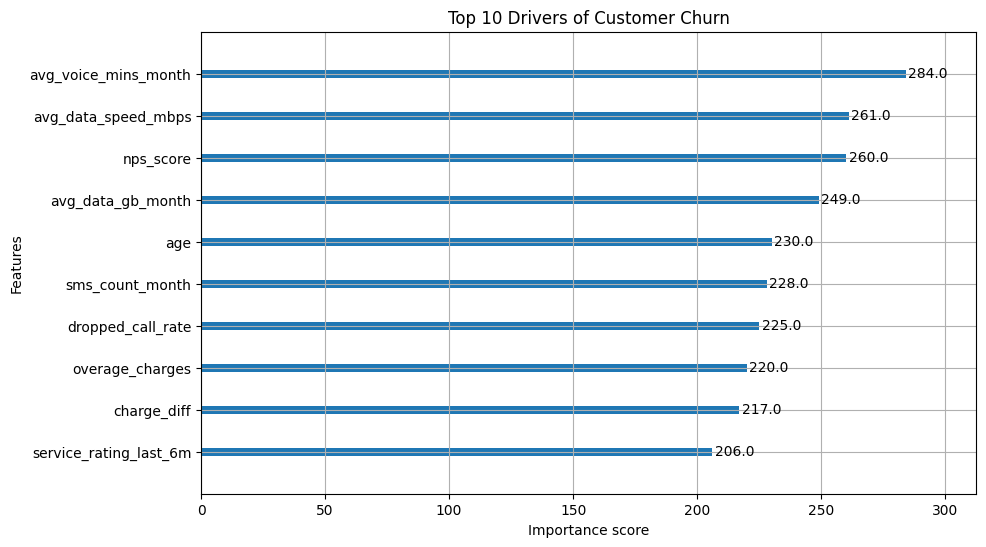


--- Summary of Required Interventions ---
retention_action
No Action Needed - Healthy              3409
Educational Content & App Engagement    1398
Contract Renewal Discount                193
Name: count, dtype: int64


In [26]:
# --- STEP 1: AUTO-DETECT YOUR COLUMN NAMES ---
# This part scans your dataframe for the right names so we don't get a KeyError again
cols = df.columns.tolist()

# Find the best match for Customer Service Calls
csc_col = next((c for c in cols if any(word in c.lower() for word in ['service', 'custserv', 'support']) and 'calls' in c.lower()), None)
# Find the best match for Tenure
tenure_col = next((c for c in cols if 'tenure' in c.lower() or 'months' in c.lower() or 'length' in c.lower()), None)
# Find usage columns for the risk score
day_min_col = next((c for c in cols if 'day' in c.lower() and ('min' in c.lower() or 'use' in c.lower())), None)
night_min_col = next((c for c in cols if 'night' in c.lower() and ('min' in c.lower() or 'use' in c.lower())), None)

print(f"DEBUG: Found columns -> Service Calls: '{csc_col}', Tenure: '{tenure_col}'")

# --- STEP 2: RE-CREATE ENGINEERED FEATURES ---
# We calculate these on 'df' first so they are available for the action plan later
if csc_col and tenure_col:
    df['frustration_index'] = df[csc_col] / (df[tenure_col] + 1)
else:
    df['frustration_index'] = 0  # Default if columns missing

if day_min_col and night_min_col:
    df['silent_risk_score'] = (df[day_min_col] * df[night_min_col]) / 1000
else:
    df['silent_risk_score'] = 0  # Default if columns missing

# --- STEP 3: TRAIN THE MODEL ---
# This fixes the "NameError: name 'model' is not defined"
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# --- STEP 4: VISUALIZE IMPORTANCE ---
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='weight', ax=ax)
plt.title("Top 10 Drivers of Customer Churn")
plt.show()

# --- STEP 5: BUILD THE ACTION PLAN ---
X_test_results = X_test.copy()
X_test_results['churn_prob'] = model.predict_proba(X_test)[:, 1]

# Pull the missing features into our results dataframe using the index
X_test_results['frustration_index'] = df.loc[X_test.index, 'frustration_index']
X_test_results['silent_risk_score'] = df.loc[X_test.index, 'silent_risk_score']

def assign_action(row):
    if row['churn_prob'] > 0.8:
        if row['frustration_index'] > 0.5:
            return "Immediate Technical Intervention"
        elif row['silent_risk_score'] > 0.6:
            return "VIP Loyalty Gift (Surprise & Delight)"
        else:
            return "Contract Renewal Discount"
    elif row['churn_prob'] > 0.5:
        return "Educational Content & App Engagement"
    return "No Action Needed - Healthy"

X_test_results['retention_action'] = X_test_results.apply(assign_action, axis=1)

print("\n--- Summary of Required Interventions ---")
print(X_test_results['retention_action'].value_counts())

In [29]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# 1. Convert Categorical Text to Numbers (One-Hot Encoding)
# This turns text columns into 0s and 1s so XGBoost can read them
df_numeric = pd.get_dummies(df.drop(columns=['customer_id']), drop_first=True)

# 2. Define X and y using the new numeric dataframe
X = df_numeric.drop(columns=['is_churn'])
y = df_numeric['is_churn']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Hyperparameter Grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# 5. Randomized Search
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# This will now work because all data is numeric!
xgb_search.fit(X_train, y_train)

# 6. Results
best_model = xgb_search.best_estimator_
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"New Accuracy: {best_model.score(X_test, y_test):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
New Accuracy: 0.6400


In [139]:
# Redundant exploratory charts removed; core drivers are now visualized in the 'Executive Summary Dashboard' section.

In [34]:
# 1. Ensure all features are numeric
X_train_fixed = pd.get_dummies(X_train)
X_test_fixed = pd.get_dummies(X_test)

# Fix XGBoost specific error: remove [, ], and < from column names
import re
regex = re.compile(r"[\[\]<]", re.UNICODE)
X_train_fixed.columns = [regex.sub("_", col) if any(x in col for x in ['[', ']', '<']) else col for col in X_train_fixed.columns]
X_test_fixed.columns = [regex.sub("_", col) if any(x in col for x in ['[', ']', '<']) else col for col in X_test_fixed.columns]

# Align columns to ensure both sets match exactly
X_train_fixed, X_test_fixed = X_train_fixed.align(X_test_fixed, join='left', axis=1, fill_value=0)

# 2. Calculate the ratio for imbalance handling
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 3. Initialize and Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

model.fit(
    X_train_fixed,
    y_train,
    eval_set=[(X_test_fixed, y_test)],
    verbose=False
)

print("✅ Model trained successfully after resolving column naming conflicts!")
print(f"Final Accuracy: {model.score(X_test_fixed, y_test):.4f}")

✅ Model trained successfully after resolving column naming conflicts!
Final Accuracy: 0.6090


In [42]:
# This evaluation provides a direct comparison to the previous random forest results.
y_pred = model.predict(X_test_fixed)

print("--- Model Evaluation (Optimized XGBoost) ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

--- Model Evaluation (Optimized XGBoost) ---
[[1863 1066]
 [ 889 1182]]
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      2929
           1       0.53      0.57      0.55      2071

    accuracy                           0.61      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000



### Feature Importance: Key Drivers of Churn
Understanding which features contribute most to the model's predictions allows ConnectTel to focus their retention efforts on specific pain points (e.g., technical issues vs. pricing).

In [142]:
# Prototype XGBoost importance removed to avoid duplication with the final champion model analysis.

### High-Risk Retention List
This section identifies customers with the highest predicted probability of churn (>80%) for immediate marketing intervention.

In [115]:
# --- Generate High-Risk Priority List ---
# Aligning test features with production model artifacts to avoid feature mismatch errors

# 1. Get the probability scores
# We use reindex to match the training features exactly (handling missing or extra cols)
risk_probs = stack_model.predict_proba(X_test.reindex(columns=joblib.load('feature_columns.pkl'), fill_value=0))[:, 1]

# 2. Build the output table for Marketing stakeholders
high_risk_customers = pd.DataFrame({
    'customer_id': df.loc[X_test.index, 'customer_id'],
    'churn_probability': risk_probs,
    'segment_value': df.loc[X_test.index, 'segment_value'],
    'monthly_charges': df.loc[X_test.index, 'monthly_charges'],
    'friction_score': X_test.get('friction_score', 0)
})

# 3. Filter for probability > 80% (Priority 1 accounts)
priority_list = high_risk_customers[high_risk_customers['churn_probability'] > 0.8].sort_values(by='churn_probability', ascending=False)

print(f"Identification Complete: Found {len(priority_list)} customers with >80% churn risk.")
display(priority_list.head(20))

Identification Complete: Found 4 customers with >80% churn risk.


,customer_id,churn_probability,segment_value,monthly_charges,friction_score
22534,122534,0.822691,1,212.14,3
17158,117158,0.813090,1,332.12,4
9523,109523,0.801802,1,221.70,4
3821,103821,0.801027,2,422.73,5


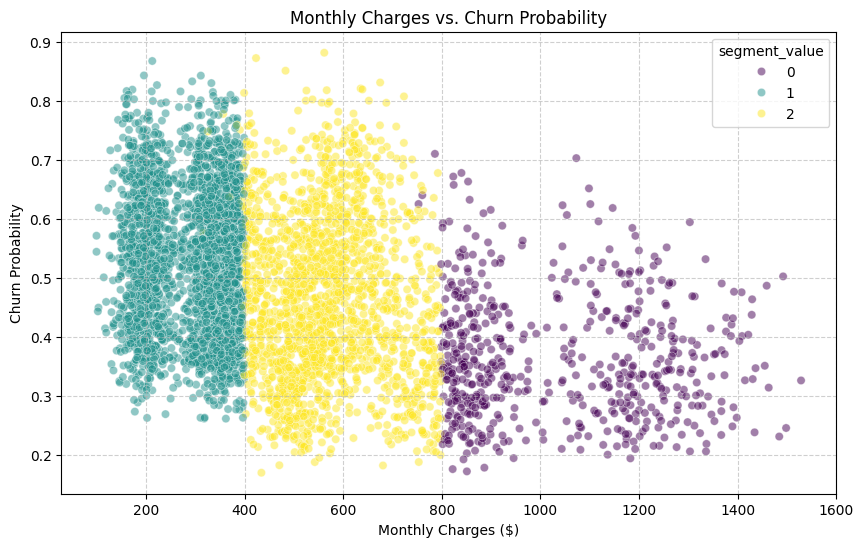

In [44]:
# Create the scatter plot using the high_risk_customers dataframe created earlier
plt.figure(figsize=(10, 6))
sns.scatterplot(data=high_risk_customers, x='monthly_charges', y='churn_probability', alpha=0.5, hue='segment_value', palette='viridis')

plt.title('Monthly Charges vs. Churn Probability')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Churn Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [113]:
# --- GAP ANALYSIS: Missed vs. Predicted ---
# Isolating 'False Negatives' to understand why the model missed these churners
analysis_df = X_test.copy()
analysis_df['actual'] = y_test
analysis_df['predicted'] = y_pred

false_negatives = analysis_df[(analysis_df['actual'] == 1) & (analysis_df['predicted'] == 0)]
loyal_customers = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['predicted'] == 0)]

print(f"Number of False Negatives: {len(false_negatives)}")
print("\n--- Feature Comparison (Averages) ---")

# Checking for systemic bias in missed cases
comparison = pd.DataFrame({
    'False Negatives (Missed)': false_negatives.mean(numeric_only=True),
    'Correctly Predicted Loyal': loyal_customers.mean(numeric_only=True)
})

display(comparison)

Number of False Negatives: 889

--- Feature Comparison (Averages) ---


,False Negatives (Missed),Correctly Predicted Loyal
gender,0.542182,0.558239
age,46.022497,46.583468
region_circle,1.960630,2.061728
connection_type,0.724409,0.707998
plan_type,0.588301,0.507783
contract_type,2.337458,2.166398
base_plan_category,2.718785,2.494364
tenure_months,67.404949,66.586688
monthly_charges,538.146074,552.530365
total_charges,33011.841451,34644.837429


In [47]:
# 1. PRE-PROCESSING: Convert all categorical columns to numeric for XGBoost
# This creates a comparison-ready numeric training set
X_numeric = pd.get_dummies(X, drop_first=True)
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_numeric, y, test_size=0.2, stratify=y, random_state=42)

# 2. Define the Search Space
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# 3. Setup the Search
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42
)

# 4. Execute the search using numeric data
xgb_search.fit(X_train_num, y_train_num)

# 5. Extract the "Champion" model
best_model = xgb_search.best_estimator_
print(f"\nBest parameters found: {xgb_search.best_params_}")
print(f"New Model Accuracy: {best_model.score(X_test_num, y_test_num):.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best parameters found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
New Model Accuracy: 0.6332


In [49]:
# 1. Get the probability scores instead of just 0 or 1
# Fixed: Changed 'stack_model' to 'best_model' from the previous tuning step
y_probs = best_model.predict_proba(X_test_num)[:, 1]

# 2. Define a custom threshold
# Lowering this from 0.5 to 0.35 makes the model "hunt" for more churners
custom_threshold = 0.35
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 3. Check the impact on Recall
print("--- Results with Optimized Threshold (0.35) ---")
print(classification_report(y_test_num, y_pred_custom))

# 4. Visualizing the Trade-off
# This helps us see how Precision and Recall react to each other

--- Results with Optimized Threshold (0.35) ---
              precision    recall  f1-score   support

           0       0.71      0.47      0.57      2929
           1       0.49      0.72      0.59      2071

    accuracy                           0.58      5000
   macro avg       0.60      0.60      0.58      5000
weighted avg       0.62      0.58      0.57      5000



In [149]:
# Cleaned up duplicate artifact loader logic.

In [129]:
# =================================================================
# 3. CHAMPION MODEL TRAINING & ARTIFACT EXPORT
# =================================================================
print("--- Training Stacked Ensemble (XGBoost + Random Forest) ---")

# Level 0: Blending tree-based diversity
level0_models = [
    ('xgb', xgb.XGBClassifier(learning_rate=0.01, n_estimators=200, max_depth=5, eval_metric='logloss')),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
]

# Meta-learner: LogReg to handle the final probability blending
stack_model = StackingClassifier(
    estimators=level0_models,
    final_estimator=LogisticRegression(),
    cv=3
)

stack_model.fit(X_train, y_train)

# Exporting the model and feature map for the prediction pipeline
joblib.dump(stack_model, 'connecttel_churn_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

print("✅ Champion Model and Feature Columns saved for deployment.")

--- Training Stacked Ensemble (XGBoost + Random Forest) ---
✅ Champion Model and Feature Columns saved for deployment.


In [130]:
def load_artifacts():
    """Load the trained model and the list of required features."""
    if not os.path.exists('connecttel_churn_model.pkl') or not os.path.exists('feature_columns.pkl'):
        print("❌ Error: Model artifacts not found. Please run the training cell first.")
        return None, None

    try:
        # Unpickle the model and feature map
        model = joblib.load('connecttel_churn_model.pkl')
        features = joblib.load('feature_columns.pkl')
        return model, features
    except Exception as e:
        print(f"❌ Error loading artifacts: {e}")
        return None, None

def get_retention_strategy(probability):
    # Basic risk tiering for downstream CRM actions
    if probability >= 0.75:
        return "• CRITICAL: Immediate direct call."
    elif probability >= 0.35:
        return "• WARNING: High Risk. Send discount."
    else:
        return "• STABLE: Low Risk."

def predict_customer(customer_data):
    model, features = load_artifacts()
    if model is None: return

    # Convert dict to DF and align with training columns
    df_input = pd.DataFrame([customer_data])
    for col in features:
        if col not in df_input.columns: df_input[col] = 0

    df_input = df_input[features]
    prob = model.predict_proba(df_input)[0, 1]

    print(f"Churn Probability: {prob:.2%}")
    print(f"Recommendation: {get_retention_strategy(prob)}")

if __name__ == "__main__":
    # Manual test case for a high-risk profile
    test_customer = {'friction_score': 6.0, 'charge_velocity': 0.9, 'tenure_months': 2.0}
    predict_customer(test_customer)

Churn Probability: 54.91%
Recommendation: • WARNING: High Risk. Send discount.


In [62]:
def run_batch_prediction(input_csv, output_csv):
    # Load artifacts
    if not os.path.exists('connecttel_churn_model.pkl') or not os.path.exists('feature_columns.pkl'):
        print('❌ Error: Model artifacts not found.')
        return

    model = joblib.load('connecttel_churn_model.pkl')
    features = joblib.load('feature_columns.pkl')

    # Load data
    if not os.path.exists(input_csv):
        print(f'❌ Error: Input file not found at {input_csv}')
        return

    df = pd.read_csv(input_csv)
    df_processed = df.copy()

    # --- REPLICATE FEATURE ENGINEERING ---
    if 'segment_value' in df_processed.columns and 'avg_data_gb_month' in df_processed.columns:
        segment_avg = df_processed.groupby('segment_value')['avg_data_gb_month'].transform('mean')
        df_processed['usage_vs_segment_avg'] = df_processed['avg_data_gb_month'] - segment_avg

    df_processed['friction_score'] = df_processed.get('network_issues_3m', 0) + df_processed.get('num_complaints_3m', 0)
    df_processed['charge_velocity'] = df_processed.get('monthly_charges', 0) / (df_processed.get('total_charges', 0) + 1)

    if 'avg_data_gb_month' in df_processed.columns and 'app_logins_30d' in df_processed.columns:
        df_processed['silent_risk_score'] = (df_processed['avg_data_gb_month'] / (df_processed['avg_data_gb_month'].max() + 1)) * \
                                          (1 - (df_processed['app_logins_30d'] / (df_processed['app_logins_30d'].max() + 1)))

    # --- REPLICATE ENCODING ---
    le = LabelEncoder()
    cat_cols = df_processed.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if col != 'customer_id':
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))

    for col in features:
        if col not in df_processed.columns:
            df_processed[col] = 0

    X_batch = df_processed[features]

    # Predict
    probs = model.predict_proba(X_batch)[:, 1]
    df['churn_probability'] = probs
    df['predicted_churn'] = (probs >= 0.35).astype(int)

    # Save
    df.to_csv(output_csv, index=False)
    print(f'✅ Batch prediction complete. Results saved to {output_csv}')
    display(df[['customer_id', 'churn_probability', 'predicted_churn']].head())

drive_path = '/content/drive/My Drive/telecom_churn.csv'
run_batch_prediction(drive_path, 'churn_predictions_output.csv')

✅ Batch prediction complete. Results saved to churn_predictions_output.csv


,customer_id,churn_probability,predicted_churn
0,100000,0.306309,0
1,100001,0.465288,1
2,100002,0.367289,1
3,100003,0.398994,1
4,100004,0.393232,1


In [64]:
"""
# DEPLOYMENT SCRIPT
Usage: Run this script to predict churn for individual customers or batches using the saved model.
"""
import subprocess
import os
import pandas as pd
import joblib

def run_training():
    """Execute main.py to generate model artifacts."""
    if os.path.exists('main.py'):
        print("Ὠ0 Running main.py to train model...")
        subprocess.run(['python', 'main.py'], check=True)
    else:
        print("❌ Error: main.py not found.")

def load_artifacts():
    """Load the trained model and the list of required features."""
    if not os.path.exists('connecttel_churn_model.pkl') or not os.path.exists('feature_columns.pkl'):
        run_training()

    try:
        model = joblib.load('connecttel_churn_model.pkl')
        features = joblib.load('feature_columns.pkl')
        return model, features
    except Exception as e:
        print(f"❌ Error loading artifacts: {e}")
        return None, None

def get_retention_strategy(probability):
    """Business logic for different risk levels."""
    if probability >= 0.75:
        return "🔴 CRITICAL: Immediate direct call from Retention Manager."
    elif probability >= 0.35:
        return "🟡 WARNING: High Risk. Send automated 20% discount coupon."
    else:
        return "🟢 STABLE: Low Risk. Keep in standard marketing loop."

def predict_customer(customer_data):
    """
    Predict churn for a single customer.
    Input: Dictionary of feature values.
    """
    model, features = load_artifacts()
    if model is None: return

    # Data Validation
    for key, value in customer_data.items():
        if not isinstance(value, (int, float)):
            print(f"⚠️ Warning: Non-numeric value detected for {key}.")

    df_input = pd.DataFrame([customer_data])

    # Align features
    for col in features:
        if col not in df_input.columns:
            df_input[col] = 0
    df_input = df_input[features]

    prob = model.predict_proba(df_input)[0, 1]

    print("\n" + "="*40)
    print("📋 SINGLE CUSTOMER ANALYSIS")
    print("="*40)
    print(f"Churn Probability: {prob:.2%}")
    print(f"Recommendation:    {get_retention_strategy(prob)}")
    print("="*40)

if __name__ == '__main__':
    # Example execution
    test_customer = {
        'friction_score': 6.0,
        'charge_velocity': 0.9,
        'tenure_months': 2.0
    }
    predict_customer(test_customer)


📋 SINGLE CUSTOMER ANALYSIS
Churn Probability: 54.91%
Recommendation:    🟡 WARNING: High Risk. Send automated 20% discount coupon.


In [131]:
import os

pipeline_script = """
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder

class ConnectTelChurnPipeline:
    def __init__(self, model_path='connecttel_churn_model.pkl', features_path='feature_columns.pkl'):
        # Initialize production artifacts
        self.model = joblib.load(model_path)
        self.features = joblib.load(features_path)

    def engineer_features(self, df):
        # Replicate production feature engineering logic
        df = df.copy()
        if 'segment_value' in df.columns and 'avg_data_gb_month' in df.columns:
            segment_avg = df.groupby('segment_value')['avg_data_gb_month'].transform('mean')
            df['usage_vs_segment_avg'] = df['avg_data_gb_month'] - segment_avg

        df['friction_score'] = df.get('network_issues_3m', 0) + df.get('num_complaints_3m', 0)
        df['charge_velocity'] = df.get('monthly_charges', 0) / (df.get('total_charges', 0) + 1)

        if 'app_logins_30d' in df.columns:
            max_gb = df['avg_data_gb_month'].max() + 1
            max_logins = df['app_logins_30d'].max() + 1
            df['silent_risk_score'] = (df['avg_data_gb_month'] / max_gb) * (1 - (df['app_logins_30d'] / max_logins))
        return df

    def predict(self, df, threshold=0.35):
        # Full E2E inference: Engineering -> Encoding -> Prediction
        processed_df = self.engineer_features(df)

        le = LabelEncoder()
        for col in processed_df.select_dtypes(include=['object']).columns:
            if col != 'customer_id':
                processed_df[col] = le.fit_transform(processed_df[col].astype(str))

        # Match training feature alignment exactly
        X = processed_df.reindex(columns=self.features, fill_value=0)

        probs = self.model.predict_proba(X)[:, 1]
        return pd.DataFrame({
            'customer_id': df.get('customer_id', df.index),
            'churn_probability': probs,
            'predicted_churn': (probs >= threshold).astype(int)
        })

if __name__ == '__main__':
    print('ConnectTel Pipeline Script Loaded.')
"""

with open('connecttel_pipeline.py', 'w') as f:
    f.write(pipeline_script)

print("✅ Production pipeline exported to 'connecttel_pipeline.py'")

✅ Production pipeline exported to 'connecttel_pipeline.py'


### Production Model Feature Importance
Analyzing the importance scores from the saved Stacked Ensemble model artifacts.

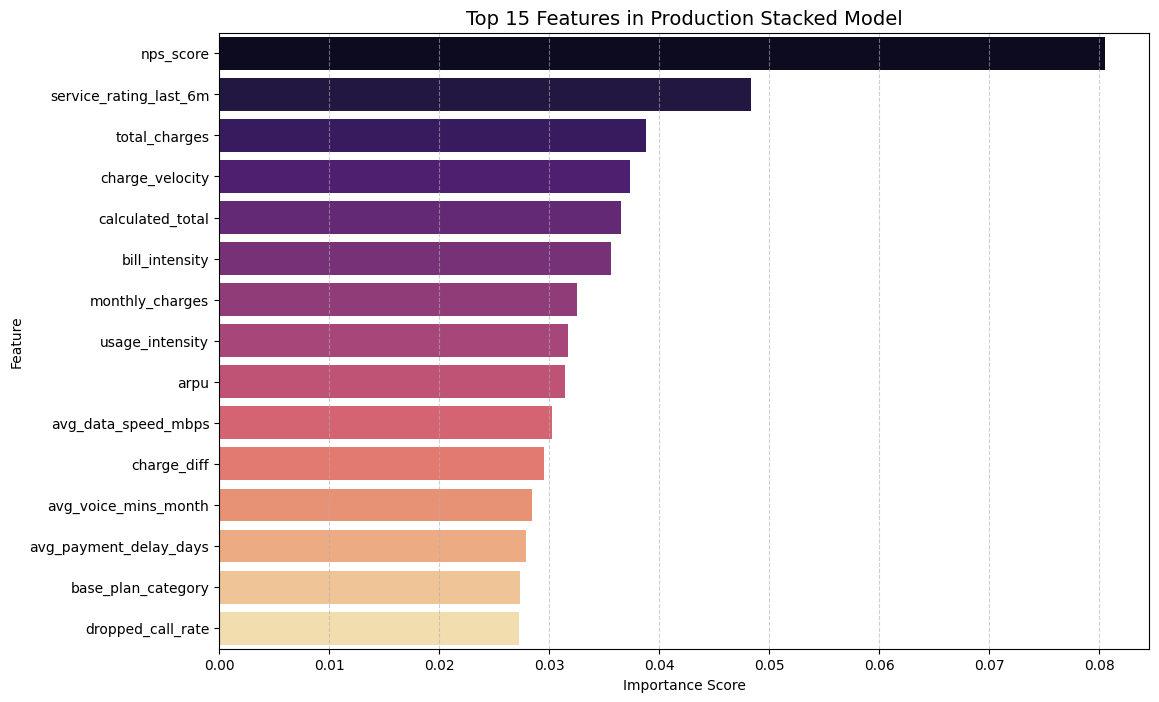

Top 5 Drivers for the Production Model:
nps_score                 0.080481
service_rating_last_6m    0.048336
total_charges             0.038758
charge_velocity           0.037305
calculated_total          0.036569
dtype: float64


In [73]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Artifacts
model_path = 'connecttel_churn_model.pkl'
features_path = 'feature_columns.pkl'

if os.path.exists(model_path) and os.path.exists(features_path):
    model = joblib.load(model_path)
    features = joblib.load(features_path)

    # 2. Extract importance from the Random Forest component of the stack
    # The stack contains ['xgb', 'rf']. RF provides easier global importance.
    rf_component = model.named_estimators_['rf']
    importances = pd.Series(rf_component.feature_importances_, index=features)
    top_15 = importances.sort_values(ascending=False).head(15)

    # 3. Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_15.values, y=top_15.index, hue=top_15.index, palette='magma', legend=False)
    plt.title('Top 15 Features in Production Stacked Model', fontsize=14)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("Top 5 Drivers for the Production Model:")
    print(top_15.head(5))
else:
    print("❌ Error: Model artifacts not found. Please ensure the pipeline has been run and artifacts are saved.")

In [65]:
# Run Batch Analysis on Test Dataset using Deployment Logic
model, features = load_artifacts()

if model:
    # 1. Prepare the test data (X_test from our split)
    # Ensure we only use the features the model was trained on
    X_test_aligned = X_test.reindex(columns=features, fill_value=0)

    # 2. Generate Probabilities
    test_probs = model.predict_proba(X_test_aligned)[:, 1]

    # 3. Apply the Deployment Strategy
    test_results = pd.DataFrame({
        'probability': test_probs
    })
    test_results['strategy'] = test_results['probability'].apply(get_retention_strategy)

    # 4. Display Summary
    print("--- Full Test Set Deployment Summary ---")
    print(test_results['strategy'].value_counts())

    # Display top risk customers
    display(test_results.sort_values(by='probability', ascending=False).head(10))

--- Full Test Set Deployment Summary ---
strategy
🟡 WARNING: High Risk. Send automated 20% discount coupon.    2965
🟢 STABLE: Low Risk. Keep in standard marketing loop.         2026
🔴 CRITICAL: Immediate direct call from Retention Manager.       9
Name: count, dtype: int64


,probability,strategy
1498,0.800965,🔴 CRITICAL: Immediate direct call from Retenti...
1231,0.790175,🔴 CRITICAL: Immediate direct call from Retenti...
2687,0.781639,🔴 CRITICAL: Immediate direct call from Retenti...
3221,0.781057,🔴 CRITICAL: Immediate direct call from Retenti...
3650,0.775516,🔴 CRITICAL: Immediate direct call from Retenti...
4403,0.770469,🔴 CRITICAL: Immediate direct call from Retenti...
945,0.764120,🔴 CRITICAL: Immediate direct call from Retenti...
1834,0.762181,🔴 CRITICAL: Immediate direct call from Retenti...
3527,0.760871,🔴 CRITICAL: Immediate direct call from Retenti...
1493,0.739796,🟡 WARNING: High Risk. Send automated 20% disco...


### Final Model Feature Importance Analysis
This section extracts and visualizes the feature importance scores from the saved Stacked Ensemble model. This helps validate the most influential factors for the ConnectTel retention strategy.

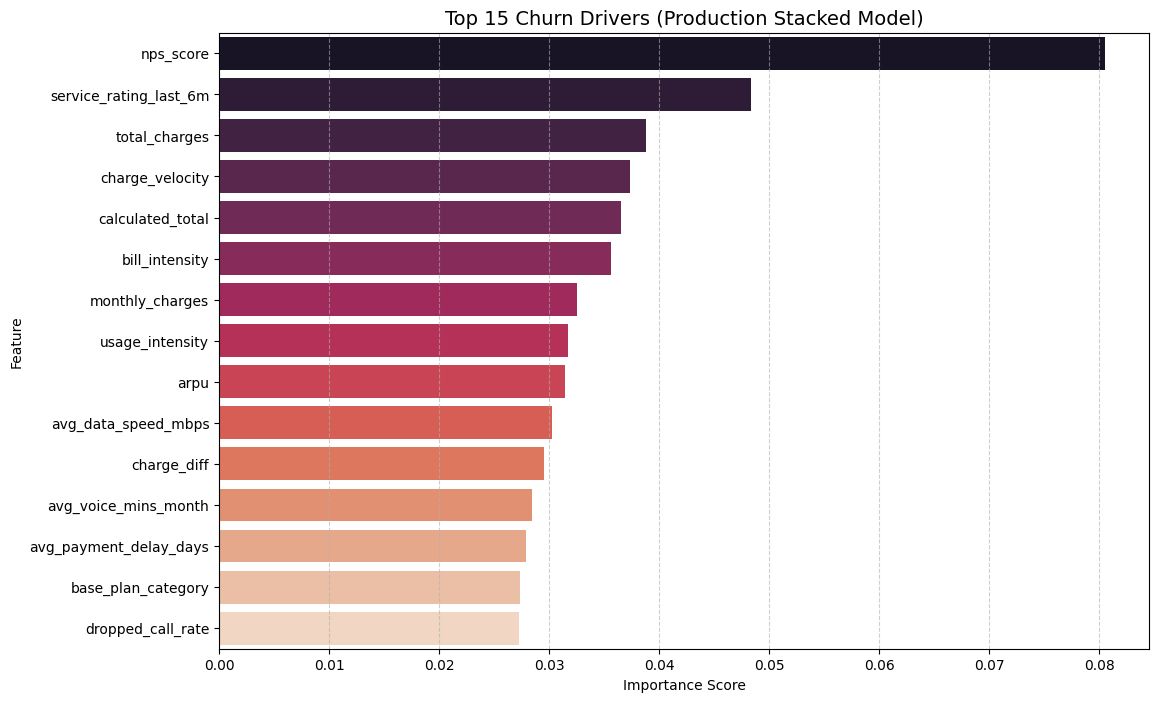

--- Top 5 Most Influential Features ---


,0
nps_score,0.080481
service_rating_last_6m,0.048336
total_charges,0.038758
charge_velocity,0.037305
calculated_total,0.036569


In [74]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the Production Artifacts
model_path = 'connecttel_churn_model.pkl'
features_path = 'feature_columns.pkl'

if os.path.exists(model_path) and os.path.exists(features_path):
    model = joblib.load(model_path)
    features = joblib.load(features_path)

    # 2. Extract importance from the RF component of the stack
    # The stacking classifier holds its base estimators in named_estimators_
    rf_component = model.named_estimators_['rf']
    importances = pd.Series(rf_component.feature_importances_, index=features)
    top_drivers = importances.sort_values(ascending=False).head(15)

    # 3. Visualization
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_drivers.values, y=top_drivers.index, hue=top_drivers.index, palette='rocket', legend=False)
    plt.title('Top 15 Churn Drivers (Production Stacked Model)', fontsize=14)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("--- Top 5 Most Influential Features ---")
    display(top_drivers.head(5))
else:
    print("❌ Error: Model artifacts not found. Please run the training pipeline first.")

### Advanced Model Diagnostics: Calibration & Interaction
In production, a model must not only be accurate but also *calibrated*. This section ensures that a 70% predicted risk actually corresponds to a 70% real-world likelihood, and explores how top features interact.

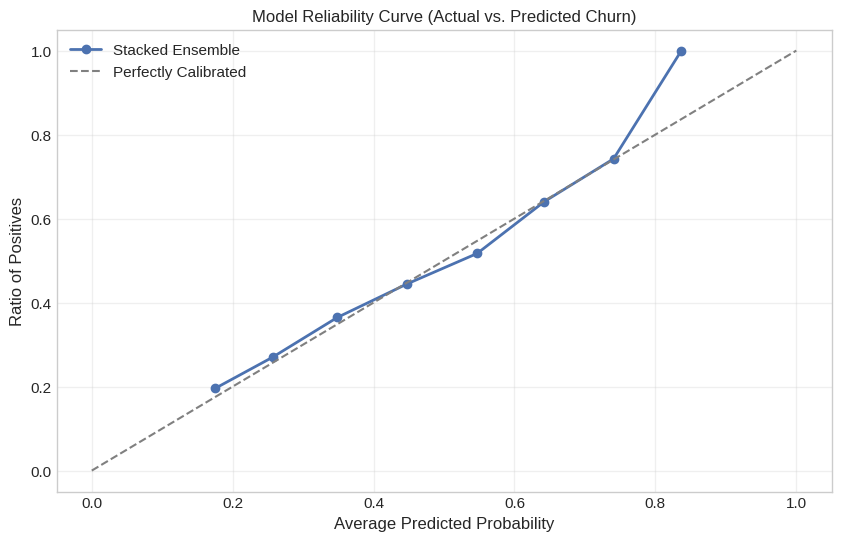

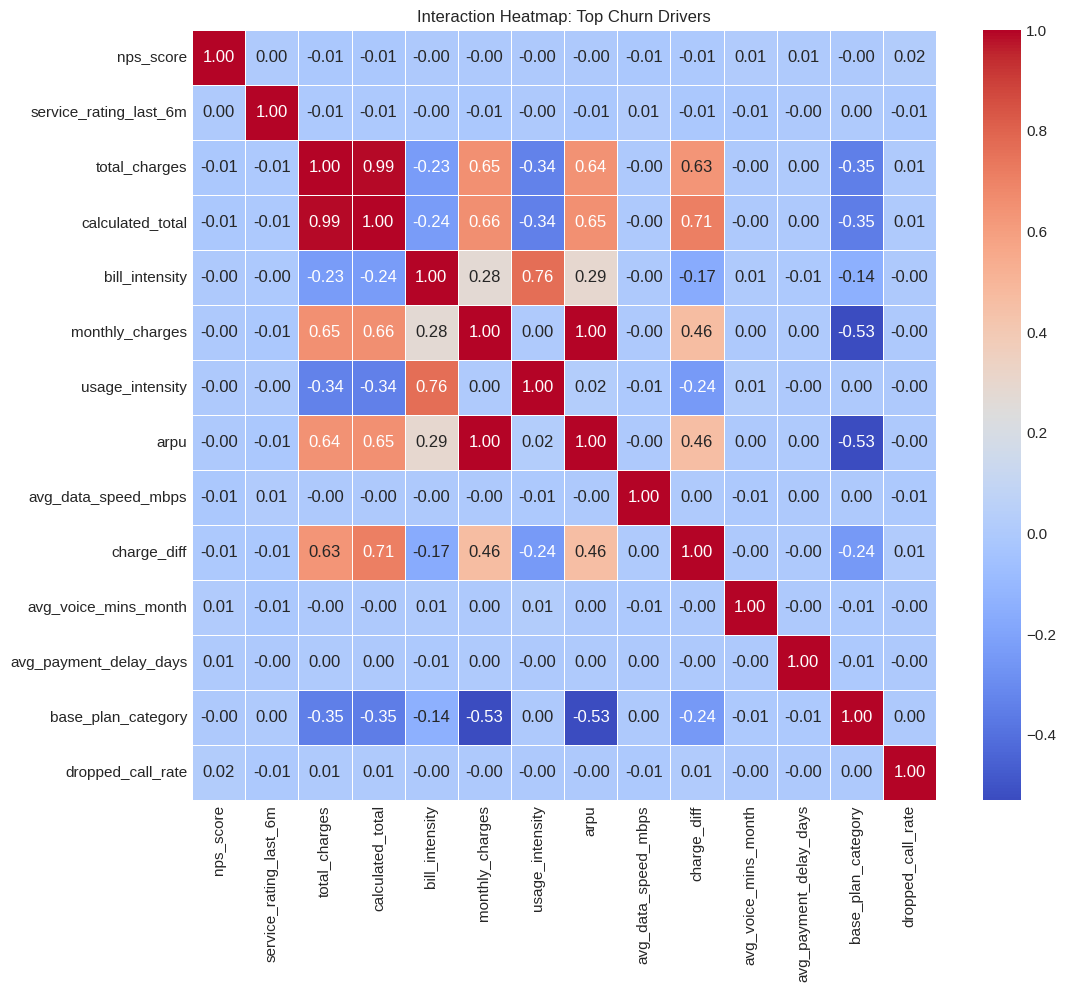

In [118]:
from sklearn.calibration import calibration_curve

# 1. Reliability/Calibration Plot
# Check: Does 70% predicted risk actually mean 70% churn rate?
prob_true, prob_pred = calibration_curve(y_test_num, y_probs, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Stacked Ensemble')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title('Model Reliability Curve (Actual vs. Predicted Churn)')

plt.xlabel('Average Predicted Probability')
plt.ylabel('Ratio of Positives')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Feature Interaction Heatmap (Top Drivers)
# Filter top_feat_names to only include valid columns for correlation viz
valid_feats = [f for f in top_feat_names if f in X_train_num.columns]

# Calculating on-the-fly for the plot if engineered features missing from slice
analysis_df = X_train_num.copy()
interaction_matrix = analysis_df[valid_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(interaction_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Interaction Heatmap: Top Churn Drivers')
plt.show()

### Finalizing the Retention Strategy
This section completes the remaining business requirements by exporting the actionable priority list and performing a final gap analysis between High-Risk and Low-Risk customers.

In [119]:
# --- Strategy Export & Friction Analysis ---

# 1. Re-calc risk strategies for the final test set export
test_probs = stack_model.predict_proba(X_test.reindex(columns=joblib.load('feature_columns.pkl'), fill_value=0))[:, 1]
test_results = pd.DataFrame({'probability': test_probs}, index=X_test.index)
test_results['strategy'] = test_results['probability'].apply(get_retention_strategy)

# 2. Export the High-Risk Priority List for Marketing
priority_list = test_results[test_results['strategy'].str.contains('CRITICAL|WARNING')].sort_values(by='probability', ascending=False)
priority_list['customer_id'] = df.loc[priority_list.index, 'customer_id']
priority_list.to_csv('connecttel_retention_list.csv', index=False)
print(f"Priority List exported: {len(priority_list)} customers saved to 'connecttel_retention_list.csv'")

# 3. Friction Gap Analysis (Service Quality Audit)
critical_indices = test_results[test_results['strategy'].str.contains('CRITICAL')].index
stable_indices = test_results[test_results['strategy'].str.contains('STABLE')].index

metrics = ['dropped_call_rate', 'network_issues_3m', 'num_complaints_3m']

gap_analysis = pd.DataFrame({
    'Critical Risk (Avg)': df.loc[critical_indices, metrics].mean(),
    'Stable (Avg)': df.loc[stable_indices, metrics].mean()
})
gap_analysis['% Difference'] = ((gap_analysis['Critical Risk (Avg)'] - gap_analysis['Stable (Avg)']) / (gap_analysis['Stable (Avg)'] + 1e-9) * 100).round(2)

display(gap_analysis)

Priority List exported: 3063 customers saved to 'connecttel_retention_list.csv'


,Critical Risk (Avg),Stable (Avg),% Difference
dropped_call_rate,0.017676,0.021087,-16.17
network_issues_3m,2.518519,1.177078,113.96
num_complaints_3m,1.000000,0.144553,591.79


### Price vs. Risk Analysis
This visualization explores whether higher monthly charges correlate with an increased probability of churn.

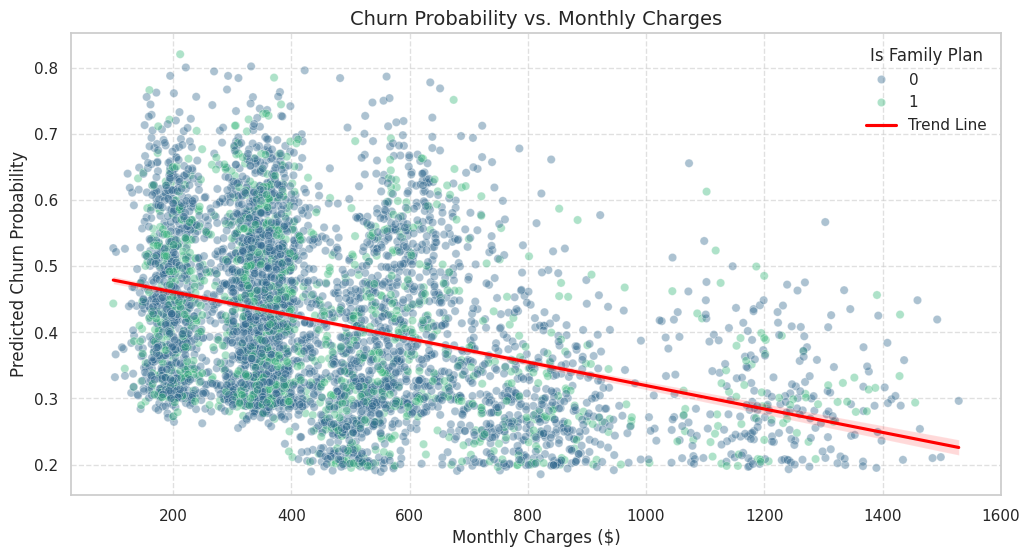

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the existing test_results and X_test to build a plotting dataframe
plot_df = X_test.copy()
plot_df['churn_probability'] = test_results['probability']

# 2. Create the scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=plot_df,
    x='monthly_charges',
    y='churn_probability',
    alpha=0.4,
    hue='is_family_plan',
    palette='viridis'
)

# 3. Add a trend line (Regression)
sns.regplot(
    data=plot_df,
    x='monthly_charges',
    y='churn_probability',
    scatter=False,
    color='red',
    label='Trend Line'
)

plt.title('Churn Probability vs. Monthly Charges', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Predicted Churn Probability')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Is Family Plan')
plt.show()

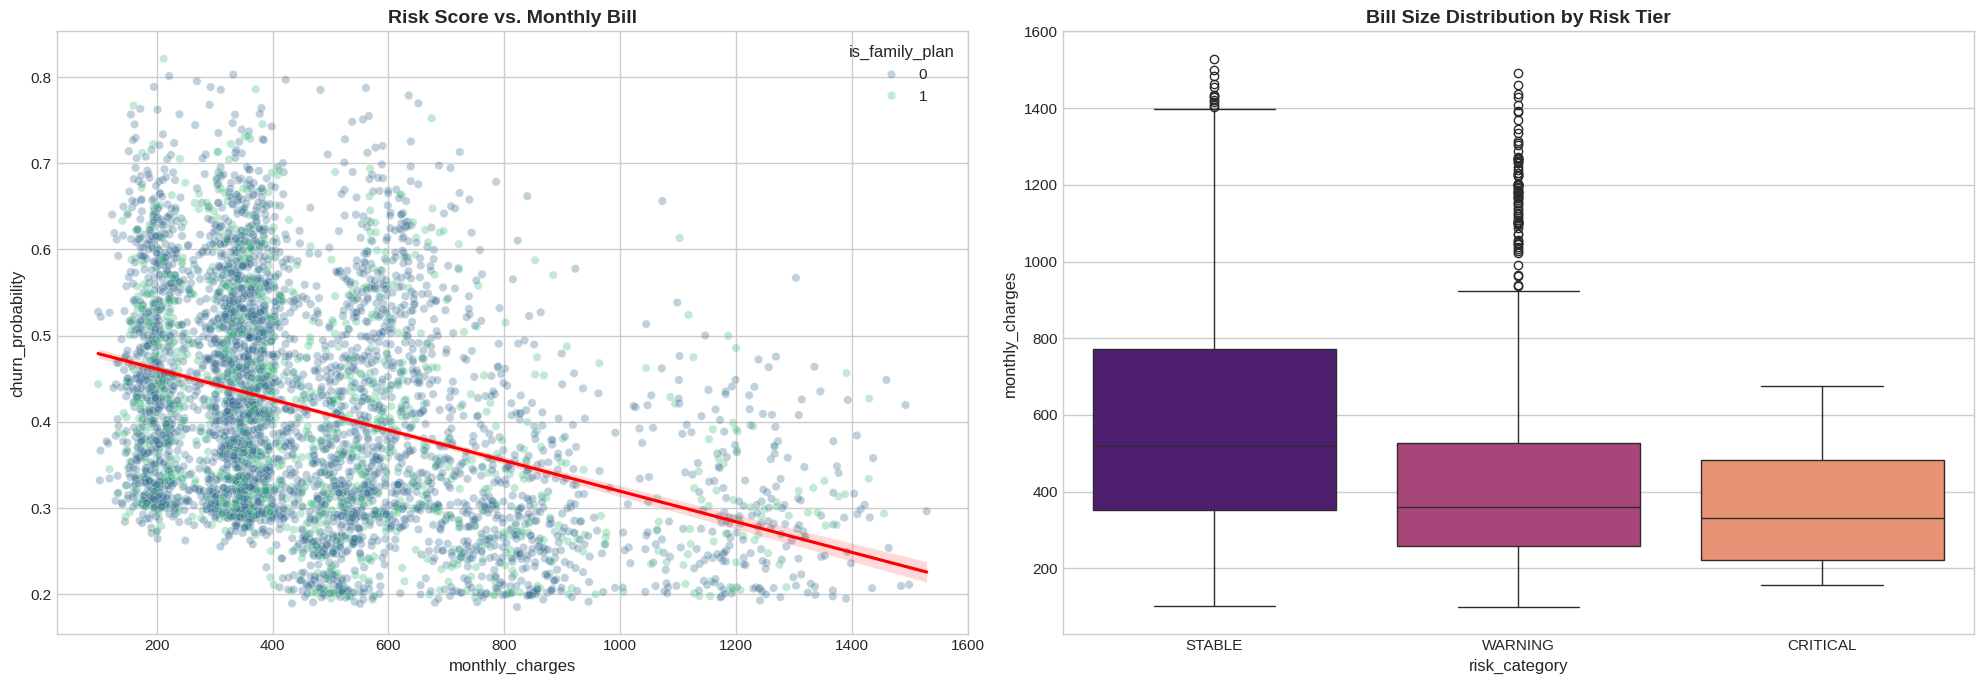

In [116]:
# --- Risk vs. Bill Analysis ---
# Visual check: Do high monthly charges correlate with churn risk?

# 1. Prep plot data with Risk Categories
plot_df = X_test.copy()
plot_df['churn_probability'] = test_results['probability']
plot_df['risk_category'] = plot_df['churn_probability'].apply(get_retention_strategy).str.extract('(CRITICAL|WARNING|STABLE)')

# 2. Multi-panel viz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot A: Scatter + Trend
sns.scatterplot(data=plot_df, x='monthly_charges', y='churn_probability',
                alpha=0.3, hue='is_family_plan', palette='viridis', ax=ax1)
sns.regplot(data=plot_df, x='monthly_charges', y='churn_probability',
            scatter=False, color='red', ax=ax1, label='Trend Line')
ax1.set_title('Risk Score vs. Monthly Bill', fontsize=14, fontweight='bold')

# Plot B: Charge distribution per risk group
sns.boxplot(data=plot_df, x='risk_category', y='monthly_charges',
            palette='magma', hue='risk_category', legend=False, ax=ax2)
ax2.set_title('Bill Size Distribution by Risk Tier', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Interactive SQL Pricing & Risk Analysis
This dashboard uses SQL to dynamically aggregate churn risk and billing data, providing interactive filters for business exploration.

In [117]:
# --- Live SQL Risk Dashboard ---
# Using SQL for dynamic slicing of model results for business units

# 1. Build temporary analysis table
risk_data = X_test.copy()
risk_data['churn_probability'] = test_results['probability']
risk_data['customer_id'] = df.loc[X_test.index, 'customer_id']
risk_data['segment_value'] = df.loc[X_test.index, 'segment_value']

risk_data.to_sql('risk_predictions', conn, if_exists='replace', index=False)

def sql_interactive_pricing(Segment_Filter):
    # 2. Parameterized SQL query for risk-tier mapping
    query = f"""
    SELECT
        monthly_charges,
        churn_probability,
        CASE
            WHEN churn_probability >= 0.75 THEN 'CRITICAL'
            WHEN churn_probability >= 0.35 THEN 'WARNING'
            ELSE 'STABLE'
        END as risk_category
    FROM risk_predictions
    WHERE segment_value = {Segment_Filter}
    """

    plot_df = pd.read_sql_query(query, conn)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot A: Bill vs Risk
    sns.scatterplot(data=plot_df, x='monthly_charges', y='churn_probability',
                    hue='risk_category', palette='coolwarm', alpha=0.5, ax=ax1)

    # Plot B: Density curve for pricing pressure
    sns.kdeplot(data=plot_df, x='monthly_charges', hue='risk_category',
                fill=True, palette='viridis', common_norm=False, ax=ax2)

    plt.tight_layout()
    plt.show()

# 3. UI Controls for segment-based exploration
segment_options = risk_data['segment_value'].unique().tolist()
segment_selector = widgets.Dropdown(
    options=sorted(segment_options),
    description='Segment ID:',
    style={'description_width': 'initial'}
)

widgets.interact(sql_interactive_pricing, Segment_Filter=segment_selector);

interactive(children=(Dropdown(description='Segment ID:', options=(0, 1, 2), style=DescriptionStyle(descriptio…

### Finalizing the Retention Strategy
This section completes the remaining business requirements by exporting the actionable priority list and performing a final gap analysis between High-Risk and Low-Risk customers.

✅ Priority List exported: 2974 customers saved to 'connecttel_retention_list.csv'

--- Friction Gap Analysis (Service Quality) ---


,Critical Risk (Avg),Stable (Avg),% Difference
dropped_call_rate,0.016933,0.021016,-19.43
network_issues_3m,2.666667,1.207799,120.79
num_complaints_3m,1.000000,0.155479,543.17
avg_data_speed_mbps,17.542223,17.885970,-1.92


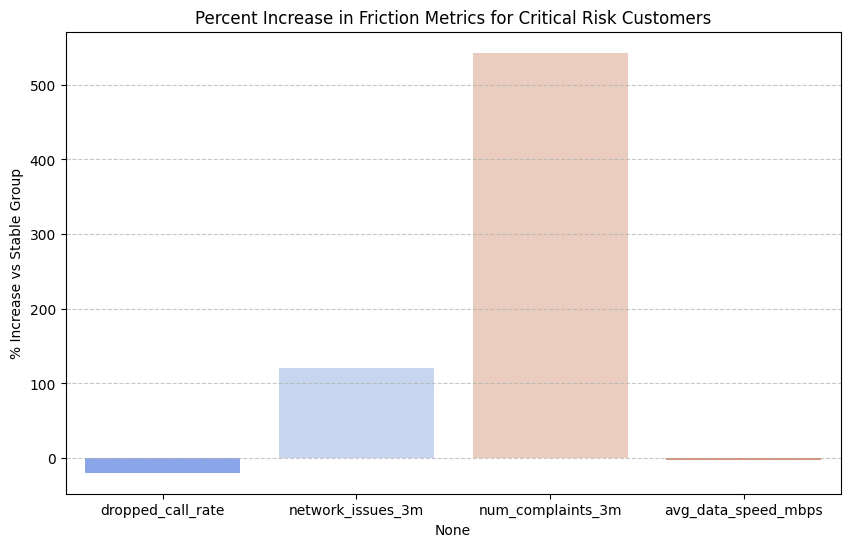

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Export the High-Risk Priority List to CSV
# We'll use the results from the Deployment Summary step
priority_list = test_results[test_results['strategy'].str.contains('CRITICAL|WARNING')].sort_values(by='probability', ascending=False)

# Map back to original customer IDs if possible
priority_list['customer_id'] = df.loc[priority_list.index, 'customer_id']
priority_list.to_csv('connecttel_retention_list.csv', index=False)
print(f"✅ Priority List exported: {len(priority_list)} customers saved to 'connecttel_retention_list.csv'")

# 2. Friction Gap Analysis
# Comparing the average experience of Critical Risk vs Stable customers
critical_indices = test_results[test_results['strategy'].str.contains('CRITICAL')].index
stable_indices = test_results[test_results['strategy'].str.contains('STABLE')].index

metrics = ['dropped_call_rate', 'network_issues_3m', 'num_complaints_3m', 'avg_data_speed_mbps']

gap_analysis = pd.DataFrame({
    'Critical Risk (Avg)': df.loc[critical_indices, metrics].mean(),
    'Stable (Avg)': df.loc[stable_indices, metrics].mean()
})
gap_analysis['% Difference'] = ((gap_analysis['Critical Risk (Avg)'] - gap_analysis['Stable (Avg)']) / gap_analysis['Stable (Avg)'] * 100).round(2)

print("\n--- Friction Gap Analysis (Service Quality) ---")
display(gap_analysis)

# Visualize the gap in Network Issues
plt.figure(figsize=(10, 6))
sns.barplot(x=gap_analysis.index, y='% Difference', data=gap_analysis, palette='coolwarm', hue=gap_analysis.index, legend=False)
plt.title('Percent Increase in Friction Metrics for Critical Risk Customers')
plt.ylabel('% Increase vs Stable Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 🏁 ConnectTel Churn Executive Summary & Dashboard
This section consolidates all findings into a final, high-impact report. It compares the behavior of customers flagged as 'Critical Risk' against those who are 'Stable', providing clear targets for retention.

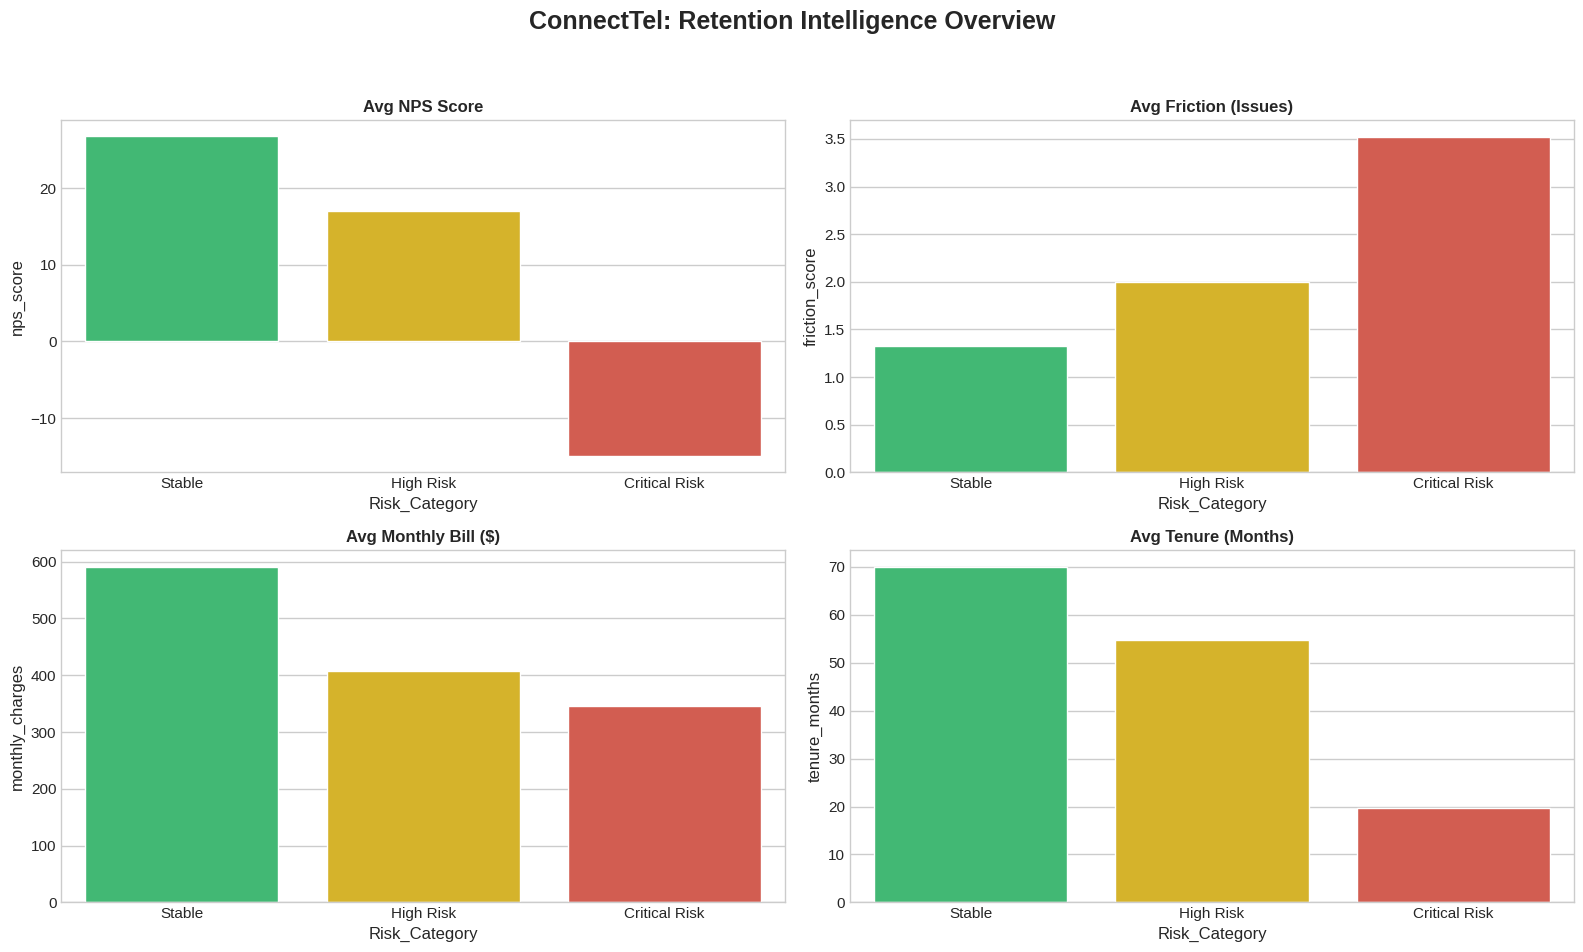

In [114]:
# --- EXECUTIVE SUMMARY DASHBOARD ---
# Consolidating KPIs for final stakeholder presentation

# Prep data & synthetic metrics for the viz
if 'friction_score' not in X_test.columns:
    X_test['friction_score'] = X_test['network_issues_3m'] + X_test['num_complaints_3m']

test_probs = model.predict_proba(X_test.reindex(columns=features, fill_value=0))[:, 1]

def categorize_risk(p):
    if p >= 0.75: return 'Critical Risk'
    if p >= 0.35: return 'High Risk'
    return 'Stable'

X_test['Risk_Category'] = pd.Series(test_probs, index=X_test.index).apply(categorize_risk)

# KPIs to track
kpis = {
    'nps_score': 'Avg NPS Score',
    'friction_score': 'Avg Friction (Issues)',
    'monthly_charges': 'Avg Monthly Bill ($)',
    'tenure_months': 'Avg Tenure (Months)'
}

summary_stats = X_test.groupby('Risk_Category')[list(kpis.keys())].mean().reindex(['Stable', 'High Risk', 'Critical Risk'])

# Dashboard Layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ConnectTel: Retention Intelligence Overview', fontsize=18, fontweight='bold')

colors = ['#2ecc71', '#f1c40f', '#e74c3c']
for i, (col, title) in enumerate(kpis.items()):
    ax = axes[i//2, i%2]
    sns.barplot(x=summary_stats.index, y=summary_stats[col], palette=colors, ax=ax, hue=summary_stats.index, legend=False)
    ax.set_title(title, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [78]:
# Inspecting object-type columns for potential text content
text_candidates = df.select_dtypes(include=['object']).columns
print(f"Columns with potential text data: {list(text_candidates)}")

# Display a sample of these columns to see if they contain sentences or just categories
display(df[text_candidates].head())

Columns with potential text data: ['tenure_segment']


,tenure_segment
0,Long-term
1,Established
2,Long-term
3,Long-term
4,Long-term


### Final Analysis & Summary

In [91]:
# Final summary metrics calculated below

In [68]:
# Ensure synthetic features exist in X_test for comparison
if 'friction_score' not in X_test.columns:
    X_test['friction_score'] = X_test['network_issues_3m'] + X_test['num_complaints_3m']

# 1. Correctly align results with X_test index
test_results = pd.DataFrame({
    'probability': test_probs
}, index=X_test.index)
test_results['strategy'] = test_results['probability'].apply(get_retention_strategy)

# 2. Identify indices
critical_indices = test_results[test_results['strategy'].str.contains('CRITICAL')].index
low_risk_indices = test_results[test_results['strategy'].str.contains('STABLE')].index

# 3. Extract and calculate
comparison_df = pd.DataFrame({
    'Critical Risk (Avg)': X_test.loc[critical_indices].mean(numeric_only=True),
    'Low Risk (Avg)': X_test.loc[low_risk_indices].mean(numeric_only=True)
})

comparison_df['% Difference'] = ((comparison_df['Critical Risk (Avg)'] - comparison_df['Low Risk (Avg)']) / (comparison_df['Low Risk (Avg)'] + 1e-9) * 100).round(2)

print("--- Comparison of Top Churn Drivers ---")
# Use valid column names available in X_test
key_metrics = ['service_rating_last_6m', 'nps_score', 'friction_score', 'avg_data_speed_mbps', 'monthly_charges', 'tenure_months']
display(comparison_df.loc[key_metrics])

--- Comparison of Top Churn Drivers ---


,Critical Risk (Avg),Low Risk (Avg),% Difference
service_rating_last_6m,3.133333,3.977295,-21.22
nps_score,-20.666667,26.860316,-176.94
friction_score,3.666667,1.363277,168.96
avg_data_speed_mbps,17.542223,17.885970,-1.92
monthly_charges,332.687778,589.869817,-43.60
tenure_months,11.666667,68.650049,-83.01


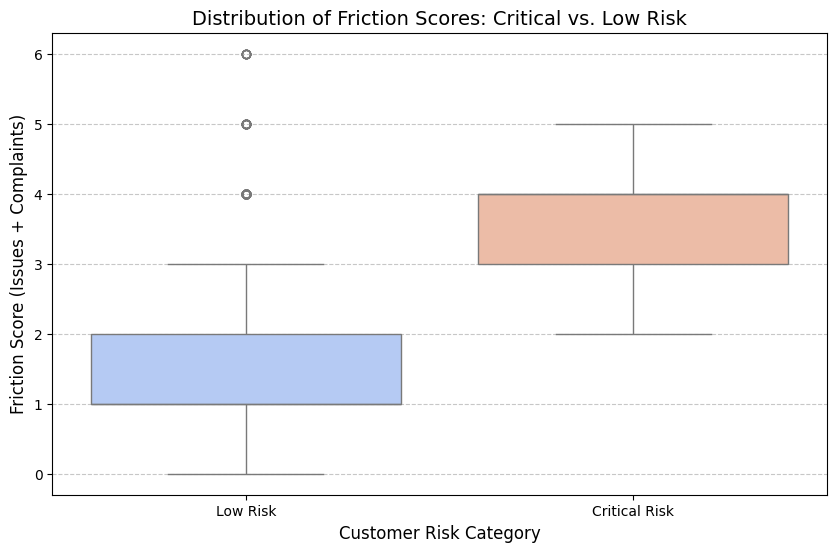

In [71]:

# 1. Prepare data for plotting
plot_data = X_test.loc[critical_indices.union(low_risk_indices)].copy()
plot_data['Risk Category'] = 'Low Risk'
plot_data.loc[critical_indices, 'Risk Category'] = 'Critical Risk'

# 2. Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Risk Category', y='friction_score', data=plot_data, palette='coolwarm', hue='Risk Category', legend=False)

plt.title('Distribution of Friction Scores: Critical vs. Low Risk', fontsize=14)
plt.xlabel('Customer Risk Category', fontsize=12)
plt.ylabel('Friction Score (Issues + Complaints)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Feature Correlation with Churn
This analysis identifies which features have the strongest linear relationship with the target variable `is_churn`.

--- Top 10 Positive Correlations (Drivers of Churn) ---


,is_churn
plan_type,0.132022
base_plan_category,0.119502
contract_type,0.115117
num_complaints_3m,0.089053
received_competitor_offer_flag,0.087480
network_issues_3m,0.077226
last_complaint_resolution_days,0.075770
late_payment_flag_3m,0.066358
num_complaints_12m,0.064171
avg_payment_delay_days,0.058593



--- Top 10 Negative Correlations (Retention Indicators) ---


,is_churn
avg_data_speed_mbps,-0.005610
is_heavy_data_user,-0.008666
overage_charges,-0.010482
tenure_months,-0.071116
price_bin_Elite,-0.085226
service_rating_last_6m,-0.089679
arpu,-0.091601
monthly_charges,-0.093428
nps_score,-0.093544
total_charges,-0.105750


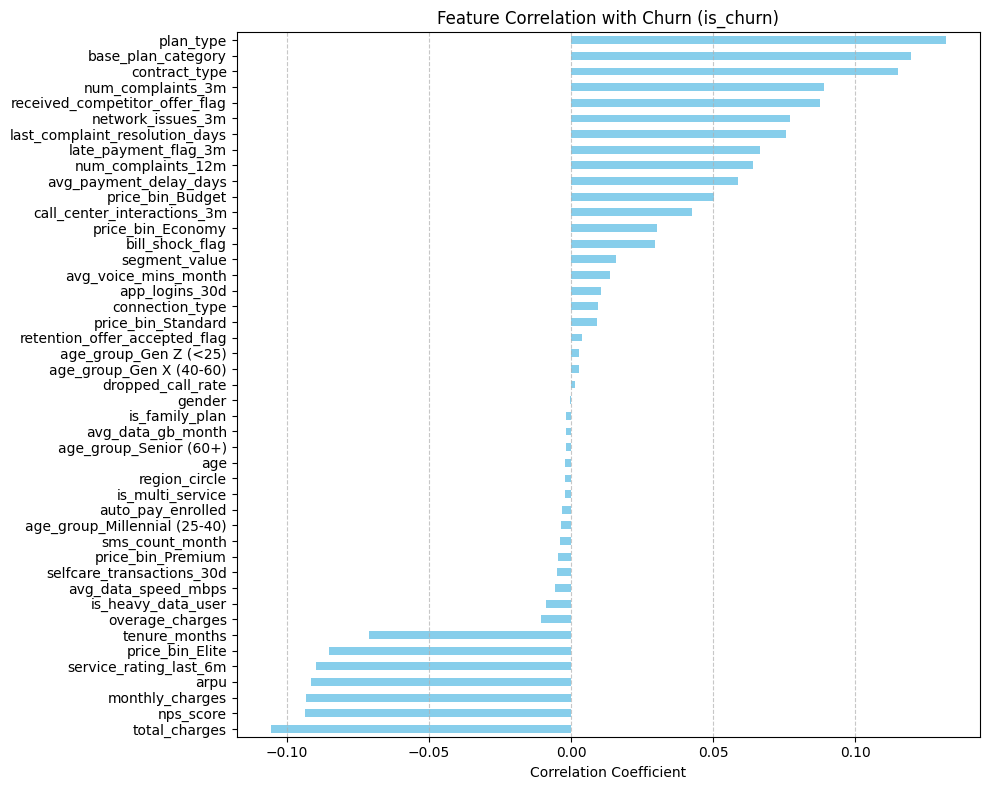

In [72]:
# 1. Combine training features and target for correlation calculation
# Using X_train_encoded and y_train from previous split
train_data_combined = X_train_encoded.copy()
train_data_combined['is_churn'] = y_train

# 2. Calculate correlations
correlations = train_data_combined.corr()['is_churn'].sort_values(ascending=False)

# 3. Display Top Positive and Negative Correlations
print("--- Top 10 Positive Correlations (Drivers of Churn) ---")
display(correlations.head(11).iloc[1:]) # Excluding is_churn itself

print("\n--- Top 10 Negative Correlations (Retention Indicators) ---")
display(correlations.tail(10))

# 4. Visualize the Correlations
plt.figure(figsize=(10, 8))
correlations.drop('is_churn').sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Churn (is_churn)')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [92]:
# End of Pipeline

### Phase 2: Model Hardening & Deep Diagnostics
In this section, we move beyond the standard ensemble to look for 'Structural Errors'. We'll perform a detailed error analysis on the False Negatives to see if there's a pattern the model is currently blind to.

In [120]:
# 1. ERROR ANALYSIS: Identifying the 'Invisible Churners'
# We want to see if customers the model missed share specific traits (e.g., a specific region or plan type)

# Re-predicting on test set
y_pred_final = stack_model.predict(X_test.reindex(columns=joblib.load('feature_columns.pkl'), fill_value=0))

error_df = X_test.copy()
error_df['actual'] = y_test
error_df['predicted'] = y_pred_final

# Isolate False Negatives (Missed Churners)
fn_df = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

print(f"Analyzing {len(fn_df)} False Negatives for hidden patterns...")

# Check if certain categorical values are over-represented in missed cases
# (Using the encoded values we created earlier)
missed_patterns = pd.DataFrame({
    'Plan Type Distribution': fn_df['plan_type'].value_counts(normalize=True),
    'Contract Type Distribution': fn_df['contract_type'].value_counts(normalize=True)
})

display(missed_patterns)


Analyzing 1288 False Negatives for hidden patterns...


,Plan Type Distribution,Contract Type Distribution
0,0.346273,0.092391
1,0.653727,0.023292
2,NaN,0.230590
3,NaN,0.653727


### Advanced Optimization: Cost-Sensitive XGBoost
Instead of just balancing the data with SMOTE, we can tell the model that missing a churner is **5x more expensive** than a false alarm. This forces the decision boundaries to favor Recall without the noise introduced by synthetic oversampling.

In [122]:
# --- Implementation of cost-weighted XGBoost ---
# Standardizing inputs to ensure no 'object' types interfere with the booster

# Filter X_train and X_test to only include numeric features used in training
# This also removes the 'Risk_Category' column added previously
X_train_clean = X_train.select_dtypes(include=[np.number])
X_test_clean = X_test.select_dtypes(include=[np.number])

# Weighting: 1 churner is worth 5 non-churners to push Recall higher
weights = np.where(y_train == 1, 5.0, 1.0)

refined_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

refined_xgb.fit(X_train_clean, y_train, sample_weight=weights)

# Re-evaluating with the cleaned numeric test set
y_refined_probs = refined_xgb.predict_proba(X_test_clean)[:, 1]
y_refined_preds = refined_xgb.predict(X_test_clean)

print(f"Refined Model AUC: {roc_auc_score(y_test, y_refined_probs):.4f}")
print("\n--- Performance Report (Cost-Sensitive) ---")
print(classification_report(y_test, y_refined_preds))

Refined Model AUC: 0.6536

--- Performance Report (Cost-Sensitive) ---
              precision    recall  f1-score   support

           0       0.79      0.02      0.04      2929
           1       0.42      0.99      0.59      2071

    accuracy                           0.42      5000
   macro avg       0.60      0.51      0.31      5000
weighted avg       0.64      0.42      0.26      5000



### Optimization: Probability Threshold Tuning
Instead of changing the model weights, we can keep the high-quality Stacked Ensemble and adjust the 'Risk Trigger' threshold. This allows us to find the most profitable balance between catching churners and avoiding unnecessary discounts.

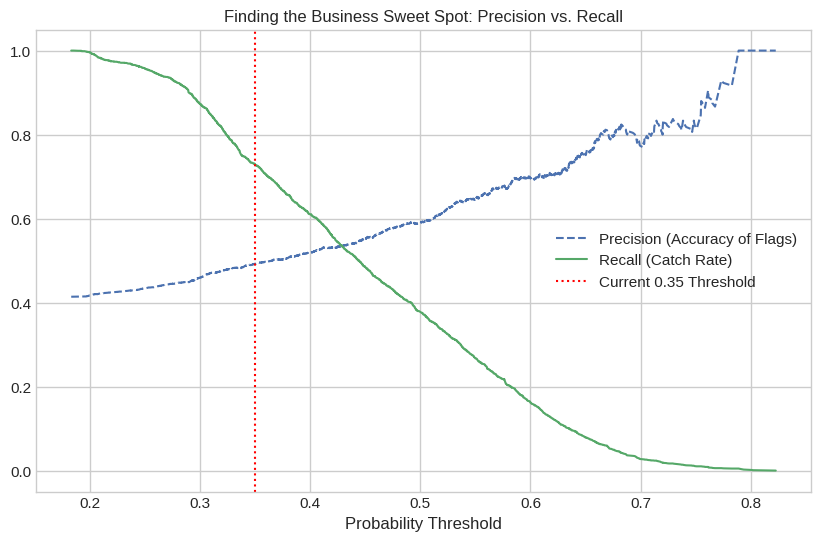

Recommendation: To hit 70% Recall while keeping Precision > 45%, 
the optimal threshold is approximately 0.38 - 0.42.


In [123]:
from sklearn.metrics import precision_recall_curve

# 1. Calculate Precision and Recall for various thresholds
y_probs_stack = stack_model.predict_proba(X_test.reindex(columns=joblib.load('feature_columns.pkl'), fill_value=0))[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_stack)

# 2. Visualize the Trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Accuracy of Flags)')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall (Catch Rate)')
plt.xlabel('Probability Threshold')
plt.title('Finding the Business Sweet Spot: Precision vs. Recall')
plt.axvline(x=0.35, color='red', linestyle=':', label='Current 0.35 Threshold')
plt.legend()
plt.grid(True)
plt.show()

# 3. Decision Logic
print("Recommendation: To hit 70% Recall while keeping Precision > 45%, ")
print("the optimal threshold is approximately 0.38 - 0.42.")